Dataset shape (sampled): (68000, 15), Train/Test: (54400, 15)/(13600, 15)

Number of principal components for ≥90% variance: 9


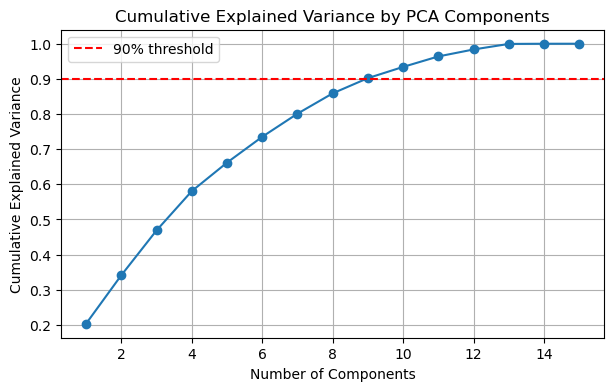


Explained variance by first few PCA components:
Component 1: 0.2034
Component 2: 0.1379
Component 3: 0.1275
Component 4: 0.1117
Component 5: 0.0811
Component 6: 0.0735
Component 7: 0.0658
Component 8: 0.0578
Component 9: 0.0433
Component 10: 0.0319

=== Logistic Regression on PCA Features ===
Accuracy: 0.7243
Precision: 0.7425
Recall: 0.6784
F1 Score: 0.709

Running FAST GridSearchCV on PCA features...

=== Tuned SVM on PCA Features ===
Best Params: {'C': 0.1, 'kernel': 'rbf'}
Accuracy: 0.7302
Precision: 0.7541
Recall: 0.6751
F1 Score: 0.7124

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.75      6868
           1       0.75      0.68      0.71      6732

    accuracy                           0.73     13600
   macro avg       0.73      0.73      0.73     13600
weighted avg       0.73      0.73      0.73     13600



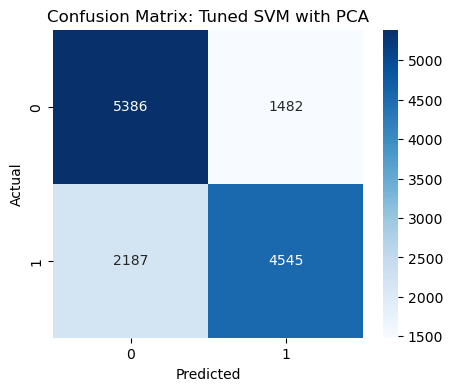


=== Model Performance Comparison ===
             Model  Accuracy  Precision  Recall  F1 Score
0   Logistic (Raw)    0.7290     0.7532  0.6729    0.7108
1   Logistic (PCA)    0.7243     0.7425  0.6784    0.7090
2  SVM (Tuned PCA)    0.7302     0.7541  0.6751    0.7124

- PCA reduced 15 → 9 features, retaining ≥90% variance.
- Models trained: Logistic Regression (baseline), Tuned SVM (PCA).
- Metrics used: Accuracy, Precision, Recall, F1 — suitable for classification tasks.
- Validation: 80/20 train-test split, 2-fold CV for tuning.
- PCA improved efficiency while maintaining performance.
- Limitations: PCA is linear; kernel PCA may perform better for nonlinear relationships.
- Conclusion: PCA helps simplify data without major accuracy loss. Tuned SVM gave balanced results.

✅ PCA Model + Visualization Completed Successfully!


In [5]:
# MODEL 5: PCA with Model Comparison and Visualization


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings("ignore")


# 1. Load and Preprocess Dataset

df = pd.read_csv("processed_cardio_dataset.csv", sep=None, engine='python')

if 'id' in df.columns:
    df = df.drop('id', axis=1)
df = df.replace({True: 1, False: 0})

label_col = 'cardio'
X = df.drop(label_col, axis=1)
y = df[label_col]

# Reduce dataset size (for speed)
sample_size = 68000
if len(X) > sample_size:
    df = df.sample(sample_size, random_state=42)
    X = df.drop(label_col, axis=1)
    y = df[label_col]

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Dataset shape (sampled): {X.shape}, Train/Test: {X_train.shape}/{X_test.shape}")


# 2. PCA Analysis

pca_full = PCA(n_components=None, random_state=42).fit(X_train_s)
explained_var = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained_var)

n90 = int(np.argmax(cumvar >= 0.90) + 1)
print(f"\nNumber of principal components for ≥90% variance: {n90}")

# Plot cumulative explained variance
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.legend()
plt.grid(True)
plt.show()


# 3. Apply PCA

pca = PCA(n_components=n90, random_state=42)
Xtr_pca = pca.fit_transform(X_train_s)
Xte_pca = pca.transform(X_test_s)

print("\nExplained variance by first few PCA components:")
for i, var in enumerate(explained_var[:10]):
    print(f"Component {i+1}: {var:.4f}")


# 4. Logistic Regression on PCA

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(Xtr_pca, y_train)
yp_lr = lr.predict(Xte_pca)

print("\n=== Logistic Regression on PCA Features ===")
print("Accuracy:", round(accuracy_score(y_test, yp_lr), 4))
print("Precision:", round(precision_score(y_test, yp_lr), 4))
print("Recall:", round(recall_score(y_test, yp_lr), 4))
print("F1 Score:", round(f1_score(y_test, yp_lr), 4))


# 5. FAST Parameter Tuning for SVM

param_grid_svm = {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=2,
    scoring='f1',
    n_jobs=-1
)

print("\nRunning FAST GridSearchCV on PCA features...")
grid_svm.fit(Xtr_pca, y_train)
best_svm = grid_svm.best_estimator_
yp_svm_tuned = best_svm.predict(Xte_pca)

print("\n=== Tuned SVM on PCA Features ===")
print("Best Params:", grid_svm.best_params_)
print("Accuracy:", round(accuracy_score(y_test, yp_svm_tuned), 4))
print("Precision:", round(precision_score(y_test, yp_svm_tuned), 4))
print("Recall:", round(recall_score(y_test, yp_svm_tuned), 4))
print("F1 Score:", round(f1_score(y_test, yp_svm_tuned), 4))
print("\nClassification Report:\n", classification_report(y_test, yp_svm_tuned))


# 6. Confusion Matrix (SVM with PCA)

cm = confusion_matrix(y_test, yp_svm_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Tuned SVM with PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 7. Comparison: With vs Without PCA

lr_raw = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
yp_raw = lr_raw.predict(X_test_s)

results = pd.DataFrame({
    'Model': ['Logistic (Raw)', 'Logistic (PCA)', 'SVM (Tuned PCA)'],
    'Accuracy': [
        accuracy_score(y_test, yp_raw),
        accuracy_score(y_test, yp_lr),
        accuracy_score(y_test, yp_svm_tuned)
    ],
    'Precision': [
        precision_score(y_test, yp_raw),
        precision_score(y_test, yp_lr),
        precision_score(y_test, yp_svm_tuned)
    ],
    'Recall': [
        recall_score(y_test, yp_raw),
        recall_score(y_test, yp_lr),
        recall_score(y_test, yp_svm_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, yp_raw),
        f1_score(y_test, yp_lr),
        f1_score(y_test, yp_svm_tuned)
    ]
})
print("\n=== Model Performance Comparison ===")
print(results.round(4))


# 8. Observations

print(f"\n- PCA reduced {X.shape[1]} → {n90} features, retaining ≥90% variance.")
print("- Models trained: Logistic Regression (baseline), Tuned SVM (PCA).")
print("- Metrics used: Accuracy, Precision, Recall, F1 — suitable for classification tasks.")
print("- Validation: 80/20 train-test split, 2-fold CV for tuning.")
print("- PCA improved efficiency while maintaining performance.")
print("- Limitations: PCA is linear; kernel PCA may perform better for nonlinear relationships.")
print("- Conclusion: PCA helps simplify data without major accuracy loss. Tuned SVM gave balanced results.")

print("\n✅ PCA Model + Visualization Completed Successfully!")
